# Description of the problem/data
Nearly half of the passengers on the spaceship Titanic were transported to another dimension. The task is to predict which passengers were transported using the records left on the spaceship. Upon examining the data, it is clear that train.csv contains a Boolean target label called Transported, indicating that supervised learning (or possibly a neural network) should be used for training. Given the large number of parameters in the dataset, the chosen approach will be to use a Decision Tree algorithm.

Ultimately, the goal is to output a CSV file containing PassengerId and Transported to indicate whether each passenger was transported. The objective is to achieve a classification accuracy of 1.

In [1]:
# import essential packages
!pip install seaborn=="v0.13.2" # supress "Futurewarning for deprecated pandas is_categorical_dtype and use_inf_as_na usage"
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.2
    Uninstalling seaborn-0.12.2:
      Successfully uninstalled seaborn-0.12.2


In [2]:
# define environmental variables
BASE_DIR = '/kaggle/input/spaceship-titanic'

In [3]:
# load given data
df_train = pd.read_csv(f'{BASE_DIR}/train.csv')
df_test = pd.read_csv(f'{BASE_DIR}/test.csv')
sample_submission_data = pd.read_csv(f'{BASE_DIR}/sample_submission.csv')

The details of the data are cited from the [Data Section](https://www.kaggle.com/competitions/spaceship-titanic/data) on Kaggle.
The difference between train.csv and test.csv is whether the Transported column is present or not.
Additionally, from the description, it is clear that multiple types of data are mixed in the Cabin column, so it needs to be separated.

> - PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
> - HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
> - CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
> - Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
> - Destination - The planet the passenger will be debarking to.
> - Age - The age of the passenger.
> - VIP - Whether the passenger has paid for special VIP service during the voyage.
> - RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
> - Name - The first and last names of the passenger.
> - Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

It can be confirmed that CryoSleep, VIP, and Transported are Boolean, HomePlanet, Cabin, Destination, and Name are strings, and all other columns contain numeric data.

In [4]:
# check the contents of train, test csv
def show_data_structure(dataframe, label):
    print(f'{label} set shape: {dataframe.shape}')
    print(f'{label} set columns: {[column for column in dataframe.columns]}')
    print(f'{label} set memory usage: {dataframe.memory_usage().sum() / 1024**2} MB')

show_data_structure(df_train, label='train')
show_data_structure(df_test, label='test')

train set shape: (8693, 14)
train set columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']
train set memory usage: 0.8706026077270508 MB
test set shape: (4277, 13)
test set columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']
test set memory usage: 0.42432403564453125 MB


In [5]:
# check the submission format
sample_submission_data.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [6]:
# peek the train data
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
# peek the test data
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


# Exploratory Data Analysis (EDA)

Now, upon examining the given data, it is clear that Age, RoomService, FoodCourt, ShoppingMall, Spa, and VRDeck are numerical data.

We will check the descriptive statistics for these data. By looking at the std and max values, it can be observed that, excluding Age, some individuals have spent an unusually high amount on services.

In [8]:
# check descriptive statistics about train data
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


Checking the proportion of people who were Transported, we can confirm that, as stated in the problem, it is approximately half.

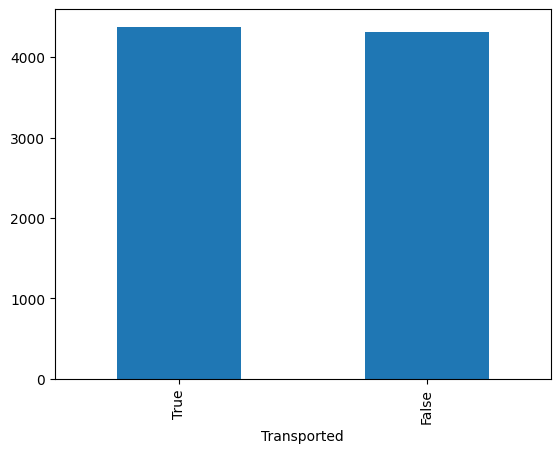

In [9]:
# plot transported vs no transported
plot_df = df_train.Transported.value_counts()
plot_df.plot(kind="bar")
plt.show()

From here, we will separate those who were Transported and those who were not, plot histograms, and check for any differences.

In [10]:
# separate data transported or not
transported_condition = df_train.Transported == True
df_no_transported = df_train[transported_condition]
df_transported = df_train[~transported_condition]

It is interesting to see that there are clearly more Transported people from Earth compared to Mars and Europe.

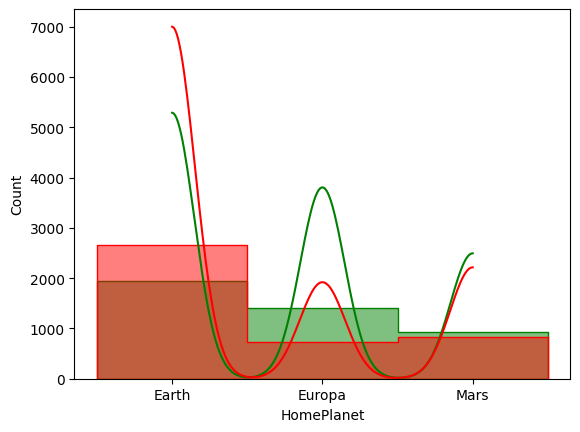

In [11]:
# plot based on HomePlanet
sns.histplot(df_no_transported.HomePlanet, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.HomePlanet, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

Comparing the values indicating whether a person chose CryoSleep during the voyage, it can be observed that among those who were Transported, there are more people who did not choose CryoSleep.

There might have been some factor that made more active individuals more likely to experience this event.

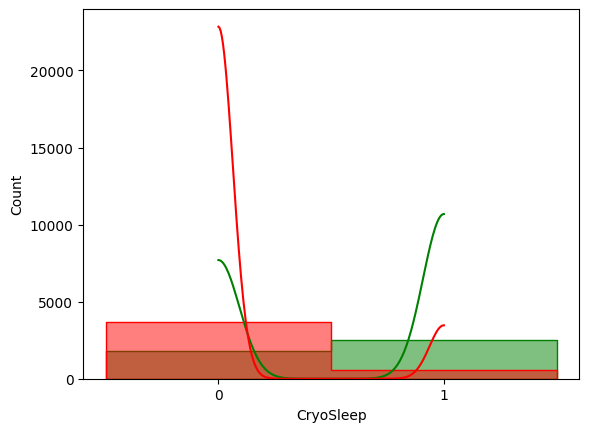

In [12]:
# plot based on CryoSleep
sns.histplot(df_no_transported.CryoSleep, 
             label='Non Transported', 
             color='green',
             bins=[-0.5, 0.5, 1.5],
             element='step',
             kde=True)
sns.histplot(df_transported.CryoSleep, 
             label='Transported', 
             color='red',
             bins=[-0.5, 0.5, 1.5],
             element='step',
             kde=True)
plt.xticks([0, 1])
plt.show()

The Destination attribute does not seem to show a significant difference between those who were Transported and those who were not.

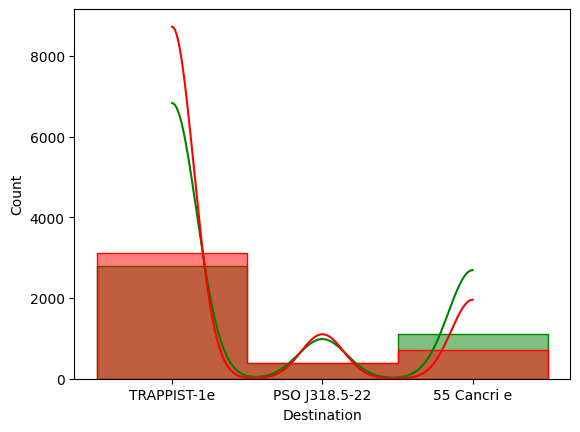

In [13]:
# plot based on Destination
sns.histplot(df_no_transported.Destination, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Destination, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

It is surprising that being a VIP does not make a significant difference in whether a person was Transported or not.

Since VIPs are usually assigned better rooms than regular passengers, factors such as room quality may not have been relevant to this incident.

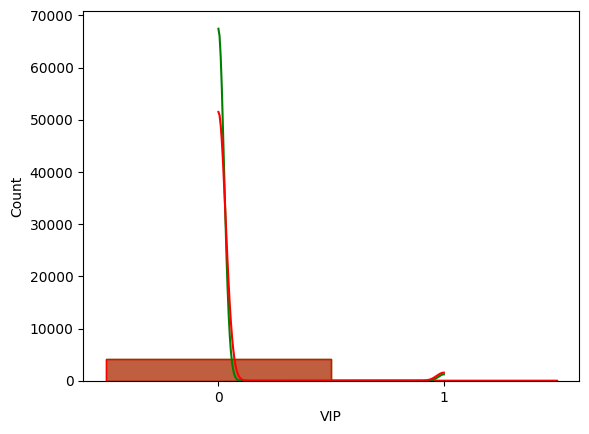

In [14]:
# plot based on VIP
sns.histplot(df_no_transported.VIP, 
             label='Non Transported', 
             color='green',
             bins=[-0.5, 0.5, 1.5],
             element='step',
             kde=True)
sns.histplot(df_transported.VIP, 
             label='Transported', 
             color='red',
             bins=[-0.5, 0.5, 1.5],
             element='step',
             kde=True)
plt.xticks([0, 1])
plt.show()

It appears that people in their 20s are more common, while those in their teens seem to be fewer.

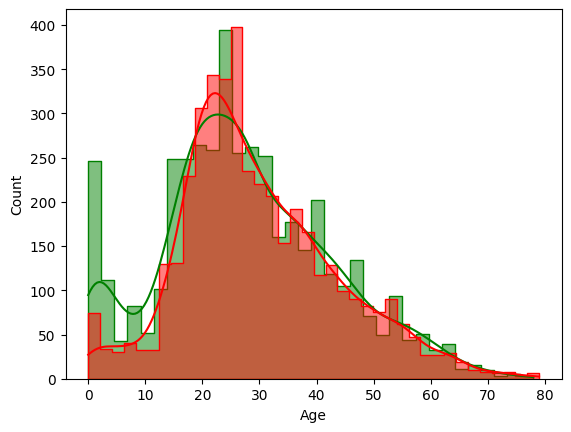

In [15]:
# plot based on Age
sns.histplot(df_no_transported.Age, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Age, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

It doesn't seem like there is any significant difference in RoomService either.

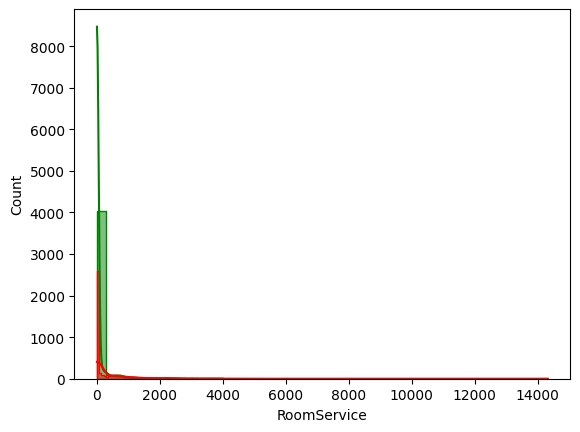

In [16]:
# plot based on RoomService
sns.histplot(df_no_transported.RoomService, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.RoomService, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

It seems there is no significant difference in the money spent on FoodCourt either.

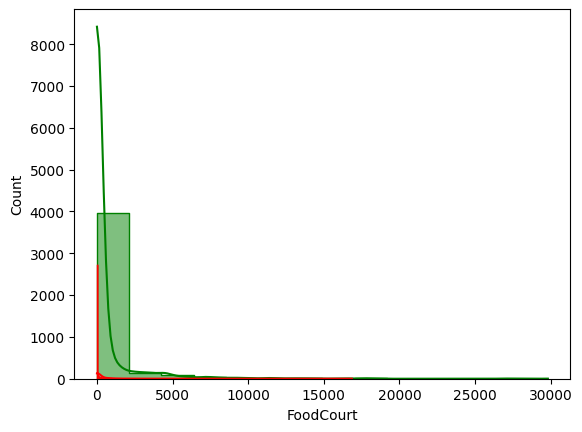

In [17]:
# plot based on FoodCourt
sns.histplot(df_no_transported.FoodCourt, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.FoodCourt, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

The amount spent on ShoppingMall also doesn't seem to have an impact.

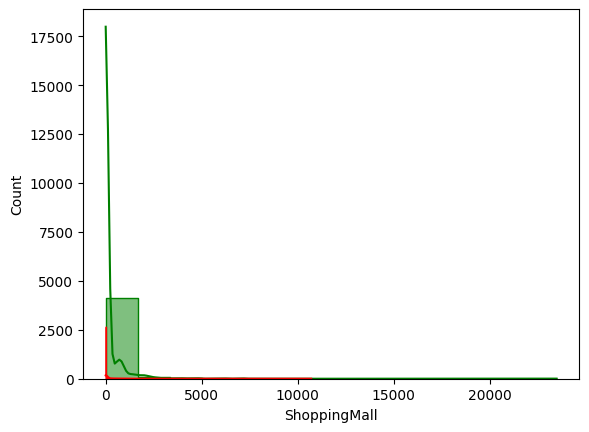

In [18]:
# plot based on ShoppingMall
sns.histplot(df_no_transported.ShoppingMall, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.ShoppingMall, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

There doesn't seem to be a significant difference in Spa either.

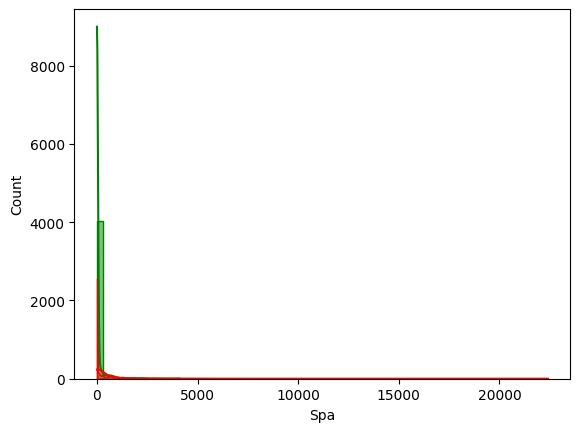

In [19]:
# plot based on Spa
sns.histplot(df_no_transported.Spa, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Spa, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

There is no difference in VRDeck either.

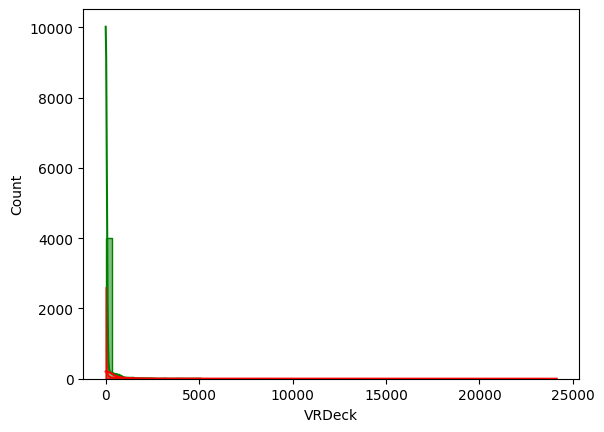

In [20]:
# plot based on VRDeck
sns.histplot(df_no_transported.VRDeck, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.VRDeck, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

What would happen if we summarize the charges for the services used?

In [21]:
try:
    df_train["Amount"] = df_train.RoomService + df_train.Spa + df_train.ShoppingMall + df_train.FoodCourt + df_train.VRDeck
except:
    print("Field does not exist")
df_no_transported = df_train[transported_condition]
df_transported = df_train[~transported_condition]

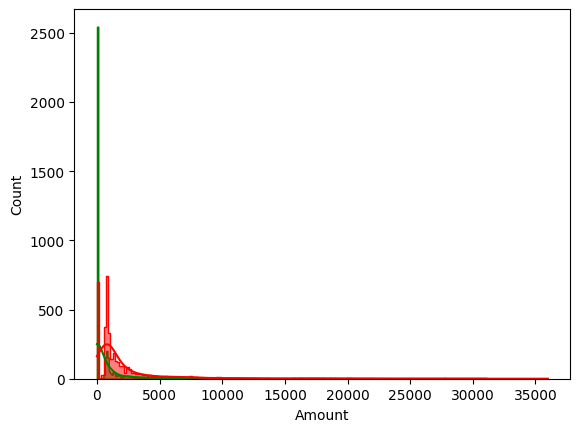

In [22]:
# plot based on Amount
sns.histplot(df_no_transported.Amount, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Amount, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

If we consider people who have a tendency for luxury based on whether they spent money on the spaceship, it appears that those who have spent money at least once are more likely to have been Transported.

In [23]:
df_train["Luxury"] = df_train.Amount > 0.0
df_no_transported = df_train[transported_condition]
df_transported = df_train[~transported_condition]

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


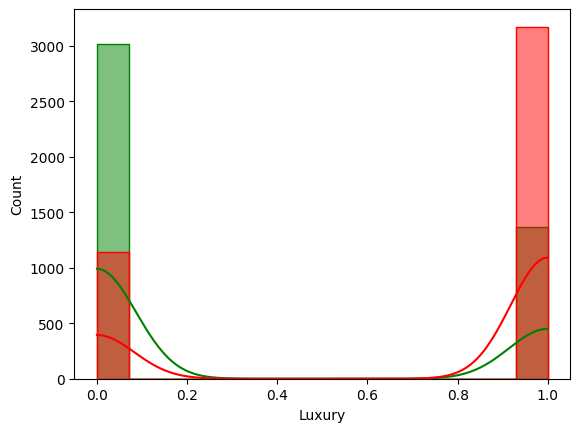

In [24]:
# plot based on Luxury
sns.histplot(df_no_transported.Luxury, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Luxury, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

Since the Cabin contains embedded information, it will be split and examined.

In [25]:
try:
    df_train[["Cabin_deck", "Cabin_num", "Cabin_side"]] = df_train.Cabin.str.split("/", expand=True)
    df_train = df_train.drop('Cabin', axis=1)
except:
    print("Field does not exist")
df_no_transported = df_train[transported_condition]
df_transported = df_train[~transported_condition]

The Cabin's Deck contains values A, B, C, D, E, F, G, and T, and it is clear that the number of victims is significantly higher on certain decks.

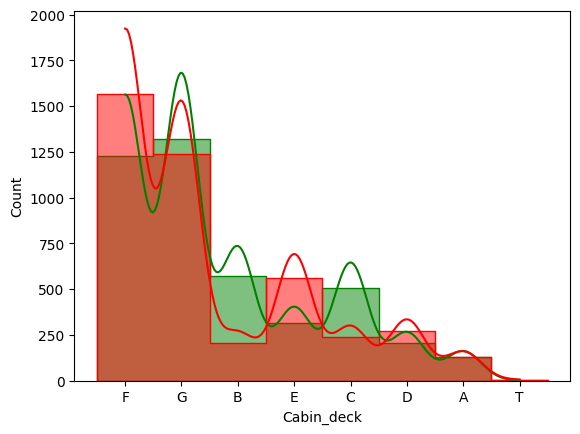

In [26]:
# plot cabin deck
sns.histplot(df_no_transported.Cabin_deck, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Cabin_deck, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

When checking the Cabin num, it appears that the number is high, and there seems to be little to no difference in the values.

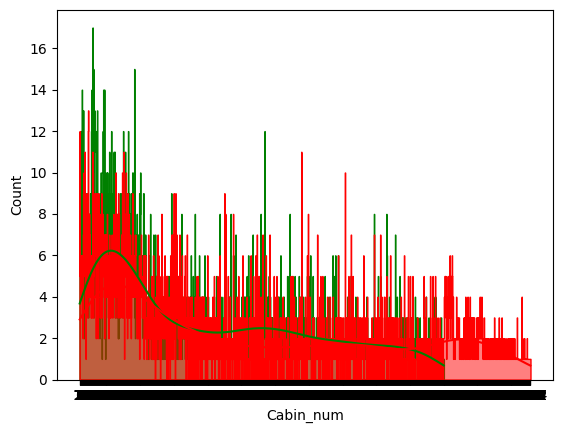

In [27]:
# plot based on Cabin number
sns.histplot(df_no_transported.Cabin_num, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Cabin_num, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

It seems there is no difference in Cabin_side either.

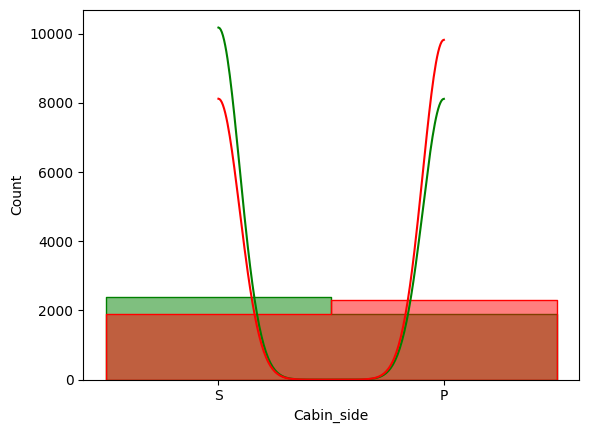

In [28]:
# plot cabin side
sns.histplot(df_no_transported.Cabin_side, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Cabin_side, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show()

The Name will be split into First Name and Last Name for further examination.

In [29]:
try:
    df_train[['First_name', 'Last_name']] = df_train.Name.str.split(" ", expand=True)
    df_train = df_train.drop('Name', axis=1)
except:
    print("Field does not exist")
df_no_transported = df_train[transported_condition]
df_transported = df_train[~transported_condition]

It seems there is no difference in First Name.

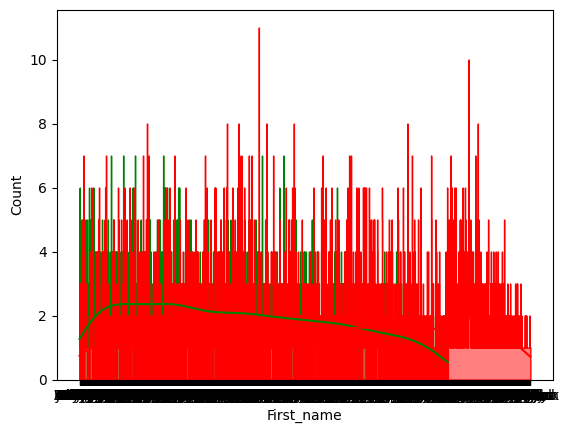

In [30]:
# plot based on first name
sns.histplot(df_no_transported.First_name, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.First_name, 
             label='Transported',
             color='red',
             element='step',
             kde=True)
plt.show()

We will similarly check the Last Name, but there doesn't seem to be any significant difference.

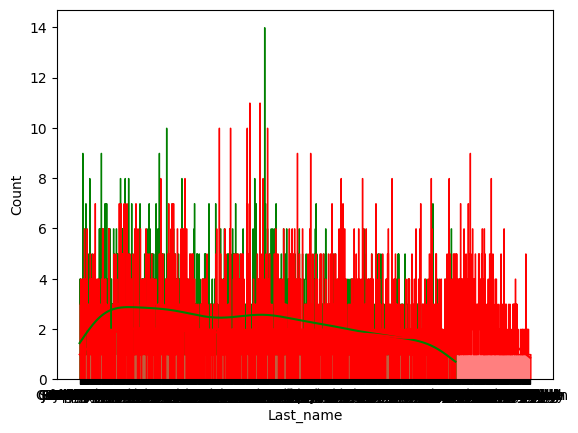

In [31]:
# plot based on last name
sns.histplot(df_no_transported.Last_name, 
             label='Non Transported', 
             color='green',
             element='step',
             kde=True)
sns.histplot(df_transported.Last_name, 
             label='Transported', 
             color='red',
             element='step',
             kde=True)
plt.show();

## Cleaning Data
Since the data is set to be recovered from a damaged spaceship, it is possible that some data is missing. We will check each column and fill in the missing values.

In [32]:
# reload given data
df_train = pd.read_csv(f'{BASE_DIR}/train.csv')
df_test = pd.read_csv(f'{BASE_DIR}/test.csv')
sample_submission_data = pd.read_csv(f'{BASE_DIR}/sample_submission.csv')

In [33]:
# check the missing value
df_train.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

If VIP, CryoSleep, FoodCourt, ShoppingMall, Spa, or VRDeck have missing values, they will be filled with 0.

In [34]:
df_train[['VIP', 'CryoSleep','RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = df_train[['VIP', 'CryoSleep','RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)
df_test[['VIP', 'CryoSleep','RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = df_test[['VIP', 'CryoSleep','RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)

Age will be filled with the average age from the train data.

In [35]:
df_train['Age'] = df_train['Age'].fillna(value=df_train.Age.mean())
df_test['Age'] = df_test['Age'].fillna(value=df_train.Age.mean())

Since we cannot determine the values for HomePlanet and Destination, the missing values will be filled with N/A.

In [36]:
df_train[['HomePlanet','Destination']] = df_train[['HomePlanet','Destination']].fillna(value='N/A')
df_test[['HomePlanet','Destination']] = df_test[['HomePlanet','Destination']].fillna(value='N/A')

The missing values in Name will be filled with "John Doe".

In [37]:
df_train['Name'] = df_train['Name'].fillna(value='John Doe')
df_test['Name'] = df_test['Name'].fillna(value='John Doe')

The missing values in Cabin will be filled with "Z/0/Z".

In [38]:
df_train['Cabin'] = df_train['Cabin'].fillna(value='Z/0/Z')
df_test['Cabin'] = df_test['Cabin'].fillna(value='Z/0/Z')

Finally, we will check to ensure that all missing values have been filled.

In [39]:
df_train.isnull().sum().sort_values(ascending=False)

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

## Select which parameters will use in our model

Based on the results of the EDA so far, Age, Home Planet, CryoSleep, Cabin deck, Amount, and Luxury appear to contain valuable information when checked with histograms, so we will incorporate them into the model.

In [40]:
try:
    df_train[["Cabin_deck", "Cabin_num", "Cabin_side"]] = df_train.Cabin.str.split("/", expand=True)
    df_train["Amount"] = df_train.RoomService + df_train.Spa + df_train.ShoppingMall + df_train.FoodCourt + df_train.VRDeck
    df_train["Luxury"] = df_train.Amount > 0.0
    df_train = df_train.drop(['Cabin', 'Cabin_num', 'Cabin_side', 'RoomService', 'Spa', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'Amount'], axis=1)
    df_train = df_train.drop(['Name', 'VIP', 'Destination'], axis=1)

    df_test[["Cabin_deck", "Cabin_num", "Cabin_side"]] = df_test.Cabin.str.split("/", expand=True)
    df_test["Amount"] = df_test.RoomService + df_test.Spa + df_test.ShoppingMall + df_test.FoodCourt + df_test.VRDeck
    df_test["Luxury"] = df_test.Amount > 0.0
    df_test = df_test.drop(['Cabin', 'Cabin_num', 'Cabin_side', 'RoomService', 'Spa', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'Amount'], axis=1)
    df_test = df_test.drop(['Name', 'VIP', 'Destination'], axis=1)
except:
    print("Field does not exist")

The Boolean type columns will bed converted to integer type.

In [41]:
df_train['Transported'] = df_train['Transported'].astype(int)
df_train['CryoSleep'] = df_train['CryoSleep'].astype(int)
df_train['Luxury'] = df_train['Luxury'].astype(int)

df_test['CryoSleep'] = df_test['CryoSleep'].astype(int)
df_test['Luxury'] = df_test['Luxury'].astype(int)

In [42]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Age,Transported,Cabin_deck,Luxury
0,0001_01,Europa,0,39.0,0,B,0
1,0002_01,Earth,0,24.0,1,F,1
2,0003_01,Europa,0,58.0,0,A,1
3,0003_02,Europa,0,33.0,0,A,1
4,0004_01,Earth,0,16.0,1,F,1


I will treat categorical data as numerical data by applying one-hot encoding and then create a correlation matrix.

In [43]:
df_train = pd.get_dummies(df_train, columns=["Cabin_deck"], dtype=int)
df_train = pd.get_dummies(df_train, columns=["HomePlanet"], dtype=int)

df_test = pd.get_dummies(df_test, columns=["Cabin_deck"], dtype=int)
df_test = pd.get_dummies(df_test, columns=["HomePlanet"], dtype=int)

In [44]:
df_train.head()

,PassengerId,CryoSleep,Age,Transported,Luxury,Cabin_deck_A,Cabin_deck_B,Cabin_deck_C,Cabin_deck_D,Cabin_deck_E,Cabin_deck_F,Cabin_deck_G,Cabin_deck_T,Cabin_deck_Z,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_N/A
0,0001_01,0,39.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0002_01,0,24.0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0
2,0003_01,0,58.0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0
3,0003_02,0,33.0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0004_01,0,16.0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0


Upon examining the results, it is interesting to note that there is a strong negative correlation between CryoSleep and Luxury. Additionally, it is clear that these variables also show some degree of correlation with Transported.

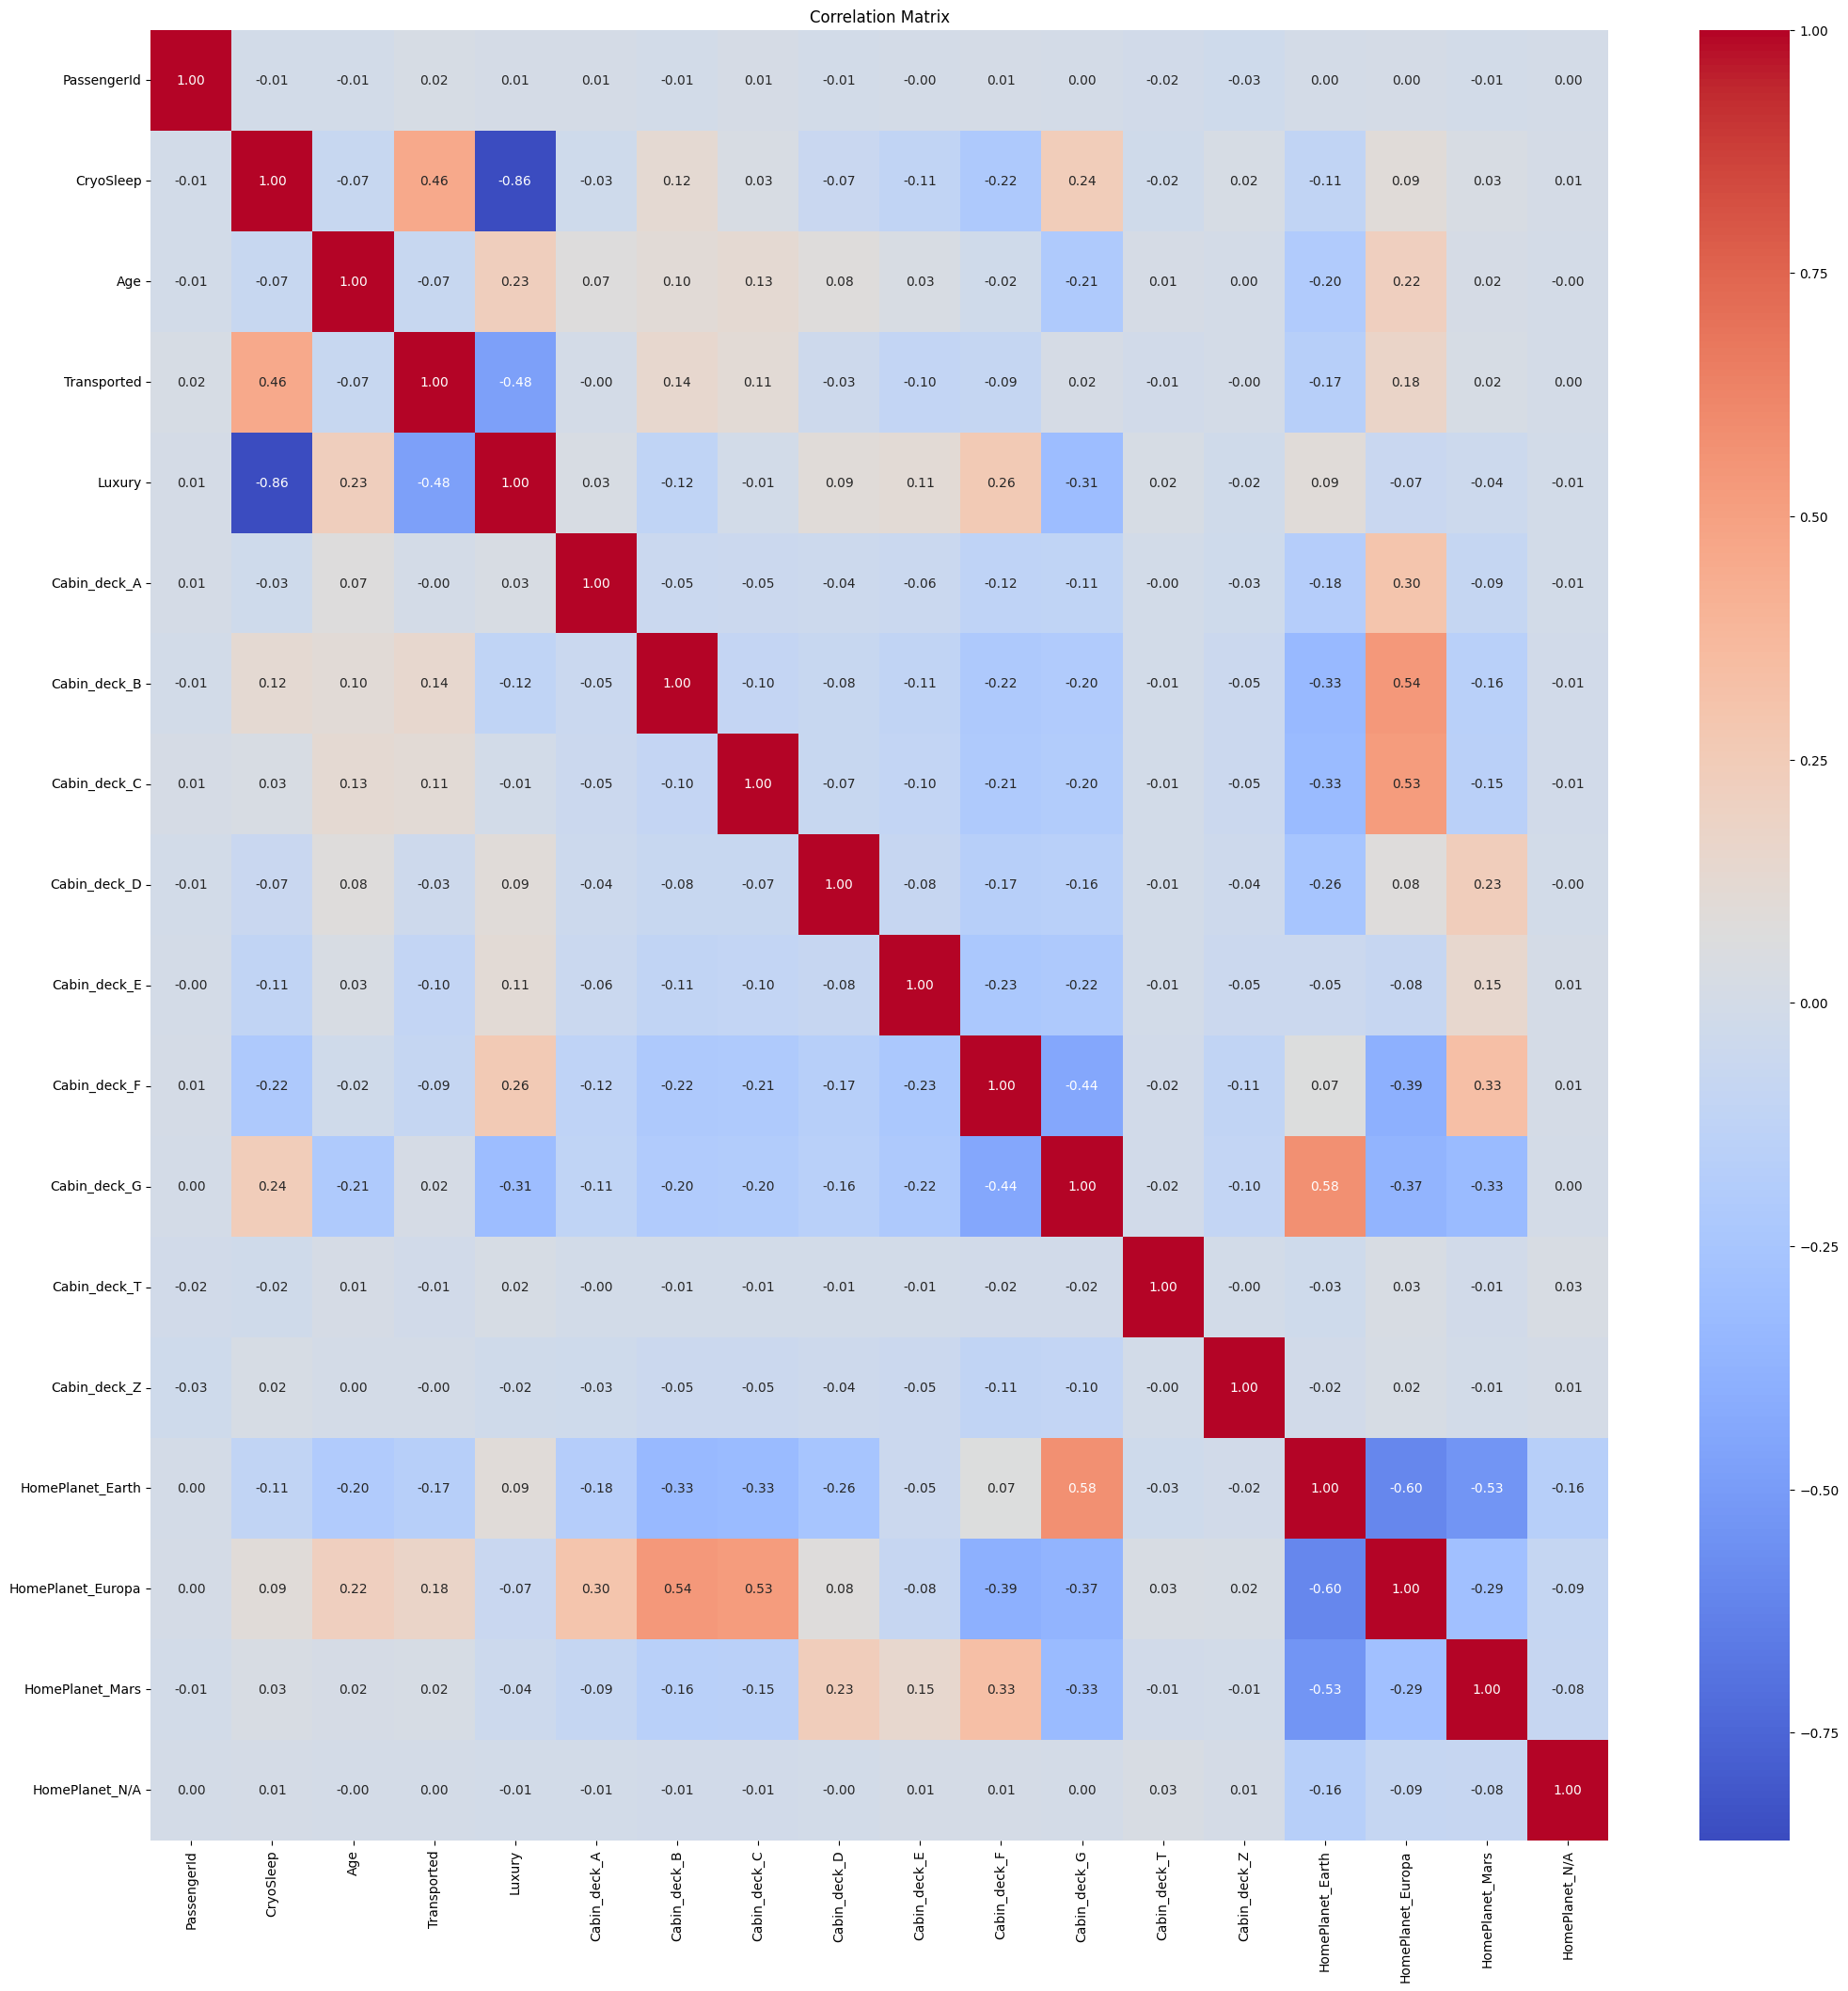

In [45]:
plt.figure(figsize=(25, 25))
sns.heatmap(df_train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Model Architecture
In this model, we will use Multi Regression Model, Random Forest, and a variant of Gradient Boosting Tree, XGBoost, to compare the accuracy of each model and select the best-performing one.

- Multi-Regression Model
- Random Forest
- Gradient Boost Tree (XGBClassifier)

## Multi-Regression Model

In [46]:
class MultiRegression:
    def __init__(self, dataset):
        X = dataset.drop(['PassengerId', 'Transported'], axis=1)
        y = dataset.Transported
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.model = LinearRegression()

    def fit(self):
        self.model.fit(self.X_train, self.y_train)

    def validate(self):
        y_pred = self.model.predict(self.X_test)
        y_pred = np.where(y_pred > 0.5, 1, 0)
        return accuracy_score(y_pred, self.y_test)

    def predict(self, dataset):
        X = dataset.drop(['PassengerId'], axis=1)
        y_pred = self.model.predict(X)
        y_pred = np.where(y_pred > 0.5, 1, 0)
        return dataset.PassengerId, y_pred

    def create_submission_file(self, passengerId, y):
        n_predictions = y.astype(bool)
        output = pd.DataFrame({'PassengerId': passengerId,
                       'Transported': n_predictions.squeeze()})
        output.to_csv('/kaggle/working/multi-regression-submission.csv', index=False)

In [47]:
multi_regression_model = MultiRegression(df_train)
multi_regression_model.fit()
multi_regression_accuracy = multi_regression_model.validate()
print(f'accuracy of multi regression: {multi_regression_accuracy}')
passengerId, y_pred = multi_regression_model.predict(df_test)
multi_regression_model.create_submission_file(passengerId, y_pred)

accuracy of multi regression: 0.7303047728579644


## Random Forest Tree

In [48]:
class RandomForestTree:
    def __init__(self, dataset, params=None):
        X = dataset.drop(['PassengerId', 'Transported'], axis=1)
        y = dataset.Transported
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        if params is None:
            self.model = RandomForestClassifier()
        else:
            self.model = RandomForestClassifier(**params)

    def optimize_parameters(self):
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False]
        }
        rf = RandomForestClassifier()
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='accuracy', cv=3, verbose=1)
        grid_search.fit(self.X_train, self.y_train)
        print("Best parameters found: ", grid_search.best_params_)
        print("Best cross-validation score: ", grid_search.best_score_)
        return grid_search.best_params_

    def fit(self):
        self.model.fit(self.X_train, self.y_train)

    def validate(self):
        y_pred = self.model.predict(self.X_test)
        y_pred = np.where(y_pred > 0.5, 1, 0)
        return accuracy_score(y_pred, self.y_test)

    def predict(self, dataset):
        X = dataset.drop(['PassengerId'], axis=1)
        y_pred = self.model.predict(X)
        y_pred = np.where(y_pred > 0.5, 1, 0)
        return dataset.PassengerId, y_pred

    def create_submission_file(self, passengerId, y, label='random-forest'):
        n_predictions = y.astype(bool)
        output = pd.DataFrame({'PassengerId': passengerId,
                       'Transported': n_predictions.squeeze()})
        output.to_csv(f'/kaggle/working/{label}-submission.csv', index=False)


In [49]:
random_forest_tree_model = RandomForestTree(df_train)
random_forest_tree_model.fit()

random_forest_tree_accuracy = random_forest_tree_model.validate()
print(f'accuracy of random_forest_tree: {random_forest_tree_accuracy}')
passengerId, y_pred = random_forest_tree_model.predict(df_test)
random_forest_tree_model.create_submission_file(passengerId, y_pred)

accuracy of random_forest_tree: 0.6986774008050604


## XGBoost

In [50]:
class XGBoost:
    def __init__(self, dataset, params=None):
        X = dataset.drop(['PassengerId', 'Transported'], axis=1)
        y = dataset.Transported
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

        if params is None:
            self.model = XGBClassifier(n_estimators=1000,
                                       learning_rate=0.01,
                                       max_depth=10)
        else:
            self.model = XGBClassifier(**params)

    def optimize_parameters(self):
        from sklearn.model_selection import GridSearchCV
        param_grid = {
            'learning_rate': [0.01, 0.1, 0.2],
            'n_estimators': [50, 100, 150],
            'max_depth': [3, 5, 7],
            'min_child_weight': [1, 5, 10],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
        xgb = XGBClassifier()
        grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='accuracy', cv=3, verbose=1)
        grid_search.fit(self.X_train, self.y_train)
        print("Best parameters found: ", grid_search.best_params_)
        print("Best cross-validation score: ", grid_search.best_score_)
        return grid_search.best_params_

    def fit(self):
        self.model.fit(self.X_train, self.y_train)

    def validate(self):
        y_pred = self.model.predict(self.X_test)
        y_pred = np.where(y_pred > 0.5, 1, 0)
        return accuracy_score(y_pred, self.y_test)

    def predict(self, dataset):
        X = dataset.drop(['PassengerId'], axis=1)
        y_pred = self.model.predict(X)
        y_pred = np.where(y_pred > 0.5, 1, 0)
        return dataset.PassengerId, y_pred

    def create_submission_file(self, passengerId, y, label='xgboost'):
        n_predictions = y.astype(bool)
        output = pd.DataFrame({'PassengerId': passengerId,
                       'Transported': n_predictions.squeeze()})
        output.to_csv(f'/kaggle/working/{label}-submission.csv', index=False)

In [51]:
xgboost_model = XGBoost(df_train)
xgboost_model.fit()

xgboost_accuracy = xgboost_model.validate()
print(f'accuracy of XGBoost: {xgboost_accuracy}')
passengerId, y_pred = xgboost_model.predict(df_test)
xgboost_model.create_submission_file(passengerId, y_pred)

accuracy of XGBoost: 0.7297297297297297


## Hyper-parameter tuning


Random Forest and Gradient Boosting have hyperparameters that can be tuned to achieve the best results. By using GridSearch, we can search for the optimal values of these parameters, apply them, and check if there is an improvement in accuracy.

### Random Forest

In [52]:
rf_optimized_params = RandomForestTree(df_train).optimize_parameters()

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validation score:  0.7430255967788323


In [53]:
rf_optimized_model = RandomForestTree(df_train, params=rf_optimized_params)
rf_optimized_model.fit()
rf_accuracy = rf_optimized_model.validate()
print(f'accuracy of random forest: {rf_accuracy}')
passengerId, y_pred = rf_optimized_model.predict(df_test)
rf_optimized_model.create_submission_file(passengerId, y_pred, label='rf_optimized')

accuracy of random forest: 0.7349051178838413


### XGBoost

In [54]:
xgboost_optimized_params = XGBoost(df_train).optimize_parameters()

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation score:  0.7415875754961174


In [55]:
xgboost_optimized_model = XGBoost(df_train, params=xgboost_optimized_params)
xgboost_optimized_model.fit()
xgboost_accuracy = xgboost_optimized_model.validate()
print(f'accuracy of XGBoost: {xgboost_accuracy}')
passengerId, y_pred = xgboost_optimized_model.predict(df_test)
xgboost_model.create_submission_file(passengerId, y_pred, label='xgboost_optimized')

accuracy of XGBoost: 0.7366302472685451


# Results and Analysis
I tried to calculate the accuracy for the three models: Multi Regression, Random Forest, and XGBoost. However, even after performing hyper-parameter tuning, there was not much difference between them, and the accuracy remained around 0.73.

| Model                  | Accuracy  |
|------------------------|-----------|
| Multi Regression        | 0.73030   |
| Random Forest           | 0.69982   |
| XGBoost                 | 0.72973   |
| Optimized Random Forest | 0.73606   |
| Optimized XGBoost       | 0.73663   |

In this Kaggle competition, accuracy is chosen as the metric, so there was a need to improve accuracy. Given that the results didn’t change much despite using different methods, it is possible that the information initially considered unnecessary in the feature engineering phase might have contributed more to the accuracy than expected.

# Discussion and Conclusion
I ran Multi Regression, Random Forest, and XGBoost models to predict the transported passengers using the damaged spaceship data, while partially filling in missing values. The results showed that there was no significant difference between the three models. In feature engineering, I had removed columns that seemed unnecessary, but perhaps that information was actually contributing to the model's performance. In the next investigation, I plan to include all those columns and compare the models, as this might improve the accuracy.

# Reference
- https://www.kaggle.com/competitions/spaceship-titanic
- https://www.kaggle.com/code/gusthema/spaceship-titanic-with-tfdf
- https://www.tensorflow.org/decision_forests